# Section 2, Figure 1

Maps the final sine-approximation loss over the two layerwise sparsity values used by the edge-popup mask search.

## Run Notes
- Run the notebook from top to bottom.
- Synthetic data only.
- Runs a grid over both layer sparsity values, so this is slower than the later single-run comparisons.
- Random sampling is intentionally exposed in the experiment cells so readers can vary it.

## Setup

In [ ]:
import math

import numpy as np
import torch
import torch.autograd as autograd
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Prefer a GPU in Colab, fall back to Apple MPS when available, and use CPU otherwise.
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

def signed_kaiming_constant_(
    tensor,
    a=0,
    mode="fan_in",
    nonlinearity="relu",
    k=0.5,
    sparsity=0,
):
    """Initialize frozen weights with signed Kaiming-style uniform samples."""
    fan = nn.init._calculate_correct_fan(tensor, mode)
    gain = nn.init.calculate_gain(nonlinearity, a)
    std = gain / math.sqrt(fan)

    # The active subnetwork keeps a k-fraction of weights, so rescale by 1/sqrt(k).
    if k != 0:
        std *= 1 / math.sqrt(k)

    with torch.no_grad():
        tensor.uniform_(-std, std)
        if sparsity > 0:
            keep_mask = (torch.rand_like(tensor) > sparsity).float()
            tensor *= keep_mask
        return tensor

class GetSubnet(autograd.Function):
    """Straight-through top-k mask used by edge-popup."""

    @staticmethod
    def forward(ctx, scores, k=0.5):
        # Convert scores to a binary mask by keeping the largest k-fraction.
        out = scores.clone()
        _, idx = scores.flatten().sort()
        cutoff = int((1 - k) * scores.numel())
        flat_out = out.flatten()
        flat_out[idx[:cutoff]] = 0
        flat_out[idx[cutoff:]] = 1
        return out

    @staticmethod
    def backward(ctx, grad):
        # Straight-through estimator: pass score gradients through unchanged.
        return grad, None

class LinearSubnet(nn.Linear):
    """Linear layer with frozen weights and trainable scores that choose the mask."""

    def __init__(
        self,
        in_features,
        out_features,
        init=signed_kaiming_constant_,
        k=0.5,
        extra_capacity=0,
        double=True,
        **kwargs,
    ):
        super().__init__(in_features, out_features, **kwargs)
        multiplier = 2 if double else 1
        self.k = k

        # Scores can be wider than the weight matrix; only the realized weight slice is used.
        self.scores = nn.Parameter(
            torch.randn(out_features, multiplier * in_features + extra_capacity)
        )
        init(self.weight)
        self.weight.requires_grad_(False)

        if self.bias is not None:
            self.bias_scores = nn.Parameter(
                torch.randn(multiplier + extra_capacity, out_features)
            )
            self.bias.requires_grad_(False)

    def forward(self, x):
        weight_mask = GetSubnet.apply(self.scores.abs(), self.k)
        weight = self.weight * weight_mask[:, : self.weight.shape[-1]]

        if self.bias is None:
            return F.linear(x, weight)

        bias_mask = GetSubnet.apply(self.bias_scores.abs(), self.k)
        bias = self.bias * bias_mask[1, : self.bias.shape[-1]]
        return F.linear(x, weight, bias)


class Network(nn.Module):
    """Small MLP assembled from masked LinearSubnet layers."""

    def __init__(
        self,
        layer_sizes,
        init=signed_kaiming_constant_,
        bias=True,
        double=True,
        extra_capacity=0,
    ):
        super().__init__()
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
            *[
                block
                for layer in layer_sizes
                for block in [
                    LinearSubnet(
                        layer[0],
                        layer[1],
                        init=init,
                        bias=bias,
                        double=double,
                        extra_capacity=extra_capacity,
                    ),
                    nn.ReLU(),
                ]
            ][:-1]
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.layers(x)

    def set_ks(self, ks):
        """Update layerwise sparsity values for a grid-search or sweep."""
        k_iter = iter(ks)
        for layer in self.layers:
            if isinstance(layer, LinearSubnet):
                layer.k = next(k_iter)

Using cuda device


## Experiment and Figure

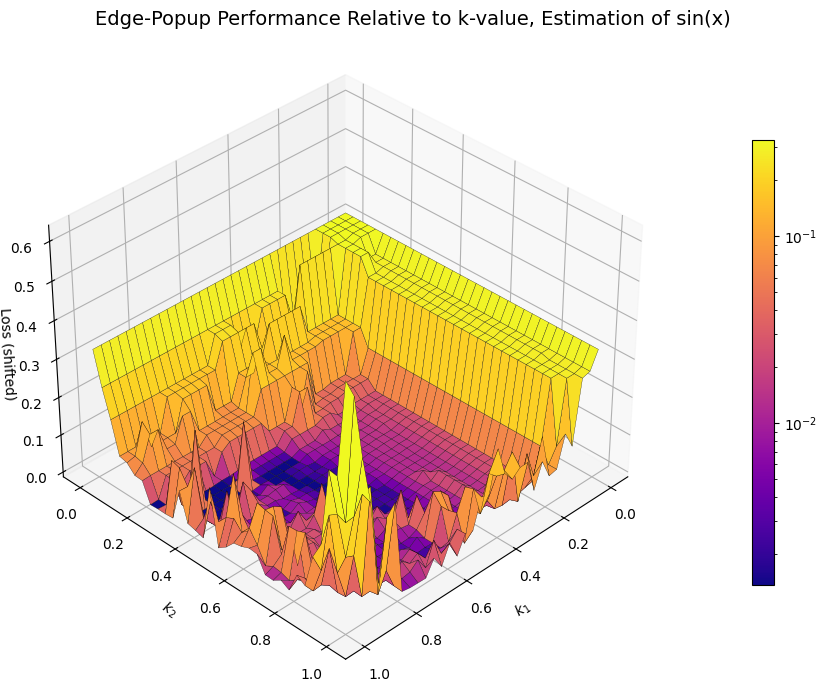

In [ ]:
# Experiment outline:
# 1. Sample a small sine-regression dataset.
# 2. Sweep every possible layerwise k value for the two masked layers.
# 3. Train scores at each grid point, evaluate held-out loss, and render the loss surface.

data_x = torch.randn(100,1).to(device)
data_y = torch.sin(data_x)
layer_sizes=[[data_x.shape[1],32],[32,data_y.shape[1]]]
num_epochs = 10
num_steps = 100
model_brute = Network(layer_sizes,bias=False,double=False).to(device)
W0 = model_brute.layers[0].weight.data.clone().to(device)
W1 = model_brute.layers[2].weight.data.clone().to(device)
S0 = model_brute.layers[0].scores.data.clone().to(device)
S1 = model_brute.layers[2].scores.data.clone().to(device)
first_layer_size = model_brute.layers[0].weight.numel()
second_layer_size = model_brute.layers[2].weight.numel()
shuffled_indices_seq = [[torch.randperm(len(data_x))[:64]for i in range(num_steps)] for e in range(num_epochs)]
data_x_test = torch.randn(100,1).to(device)
data_y_test = torch.sin(data_x_test)
Z = np.zeros((first_layer_size + 1, second_layer_size + 1))
for k1 in range(first_layer_size+1):
  for k2 in range(second_layer_size+1):
    model_brute.layers[0].weight.data = W0.clone()
    model_brute.layers[2].weight.data = W1.clone()
    model_brute.layers[0].scores.data = S0.clone()
    model_brute.layers[2].scores.data = S1.clone()
    model_brute.set_ks([k1/(first_layer_size),k2/(second_layer_size)])
    optimizer_brute=torch.optim.Adam(model_brute.parameters())
    for e in range(num_epochs):
      for i in range(num_steps):
        optimizer_brute.zero_grad()
        shuffled_indices = shuffled_indices_seq[e][i]
        loss=nn.MSELoss()(model_brute(data_x[shuffled_indices]),data_y[shuffled_indices])
        loss.backward()
        optimizer_brute.step()
    Z[k1, k2] = nn.MSELoss()(model_brute(data_x_test), data_y_test).item()
# ------------------------------------------------------------
# Build the k-grid
# ------------------------------------------------------------

k1_vals = np.array([k1 / (first_layer_size) for k1 in range(first_layer_size + 1)])
k2_vals = np.array([k2 / (second_layer_size) for k2 in range(second_layer_size + 1)])
K1, K2 = np.meshgrid(k1_vals, k2_vals, indexing='ij')

# ------------------------------------------------------------
# Plot 3D mesh surface
# ------------------------------------------------------------

Z_centered = Z - Z.min()
Z_safe = Z_centered + 1e-12

vmax = np.percentile(Z_safe, 95)
vmin = np.percentile(Z_safe, 5)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    K1, K2, Z_safe,
    cmap='plasma',
    norm=LogNorm(vmin=vmin, vmax=vmax),
    edgecolor='k',
    linewidth=0.2,
    antialiased=True
)
ax.view_init(35, 45)
ax.set_xlabel(r'$k_1$')
ax.set_ylabel(r'$k_2$')
ax.set_zlabel('Loss (shifted)',labelpad=-1)

fig.colorbar(surf, ax=ax, shrink=0.7, pad=0.10)
plt.suptitle("Edge-Popup Performance Relative to k-value, Estimation of sin(x)", fontsize=14)
plt.tight_layout()
plt.show()